In [1]:
import numpy as np
import pickle
import warnings

from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn_extra.cluster import KMedoids

from matplotlib import pyplot as plt

In [15]:
with open('card_game/eda_results/eda_trial8.pkl', 'rb') as f:
    results = pickle.load(f)
# with open(f'data/eda_results/eda_human_pass{0}_90bestother_weighted.pkl', 'rb') as f:
#         results = pickle.load(f)
pf = results['converged_pf_table'][-10]
n_obj = 5
ref_sol = np.array([75, 72, 90, 112, 102])

In [16]:
z_ideal = pf.max(axis=0)
z_nadir = pf.min(axis=0)
denom = z_ideal - z_nadir
z_pf = (pf - z_nadir) / denom

if not np.isfinite(z_pf).all():
    raise ValueError(
        "Invalid normalized Pareto front: z_pf contains NaN/Inf. "
    )

 # select only the dense pf
# nbrs = NearestNeighbors(n_neighbors=min(10+1, len(z_pf))).fit(z_pf)
# dist, _ = nbrs.kneighbors(z_pf)
# sparse_score = dist[:, 1:].mean(axis=1)
# cutoff = np.quantile(sparse_score, 0.8)
# keep = sparse_score <= cutoff
# z_pf_dense = z_pf[keep]
# pf_dense = pf[keep]

z_center = np.median(z_pf, axis=0)
z_dist = np.linalg.norm(z_pf - z_center, axis=1) 
center_sol = pf[z_dist.argmin()]
# plot

# The most extreme
# extreme_sols = [pf[z_pf[:, i].argmax()] for i in range(n_obj)]
# plot

# # 75 pecentile extreme
# p75_list = [np.percentile(z_pf[:, i], 75) for i in range(n_obj)]
# extreme_sols = []
# for i in range(n_obj):
#     diff_main = np.abs(z_pf[:, i] - p75_list[i])
#     idx_all = np.where(diff_main == diff_main.min())[0]
#     candidate_sols = pf[idx_all]
#     candidate_sols_z = z_pf[idx_all]
#     diff_others = []
#     for j in range(n_obj):
#         if j == i:
#             continue
#         diff_other = np.abs(candidate_sols_z[:, j] - p75_list[j])
#         # diff_other = z_pf[:, j].max() - candidate_sols_z[:, j]
#         diff_others.append(diff_other)
#     diff_others = np.column_stack(diff_others)
#     diff_others_sum = diff_others.sum(axis=1)
#     idx_min_all = np.where(diff_others_sum == diff_others_sum.min())[0]
#     if len(idx_min_all) > 1:
#         warnings.warn(
#         f"Multiple minima found for objective {i}: indices {idx_all}. Using the first one."
#     )
#     idx_min = idx_min_all[0] # extract a scalar no matter the number of minima
#     sol = candidate_sols[idx_min]
#     extreme_sols.append(sol)
# ## plot

# percentile
p90_list = [np.percentile(z_pf[:, i], 90) for i in range(n_obj)]
extreme_sols = []
for i in range(n_obj):
    diff_main = np.abs(z_pf[:, i] - p90_list[i])
    idx_all = np.where(diff_main == diff_main.min())[0]
    candidate_sols = pf[idx_all]
    candidate_sols_z = z_pf[idx_all]
    diff_others = []
    for j in range(n_obj):
        if j == i:
            continue
        # diff_other = np.abs(candidate_sols_z[:, j] - p90_list[j])
        diff_other = z_pf[:, j].max() - candidate_sols_z[:, j]
        diff_others.append(diff_other)
    diff_others = np.column_stack(diff_others)
    diff_others_sum = diff_others.sum(axis=1)
    idx_min_all = np.where(diff_others_sum == diff_others_sum.min())[0]
    if len(idx_min_all) > 1:
        warnings.warn(
        f"Multiple minima found for objective {i}: indices {idx_min_all}. Using the first one."
    )
    idx_min = idx_min_all[0] # extract a scalar no matter the number of minima
    sol = candidate_sols[idx_min]
    extreme_sols.append(sol)

selected_sols = np.array([*extreme_sols, center_sol])

In [22]:
z_ideal = pf.max(axis=0)
z_nadir = pf.min(axis=0)
denom = z_ideal - z_nadir
z_pf = (pf - z_nadir) / denom

# density filter: remove sparse outer points
nbrs = NearestNeighbors(n_neighbors=min(10+1, len(z_pf))).fit(z_pf)
dist, _ = nbrs.kneighbors(z_pf)
sparse_score = dist[:, 1:].mean(axis=1)
cutoff = np.quantile(sparse_score, 0.8)
keep = sparse_score <= cutoff
z_pf_dense = z_pf[keep]
pf_dense = pf[keep]

# find center
z_center = np.median(z_pf_dense, axis=0)
z_dist = np.linalg.norm(z_pf_dense - z_center, axis=1) 
center_sol = pf_dense[z_dist.argmin()]

extreme_sols = [pf_dense[z_pf_dense[:, i].argmax()] for i in range(n_obj)]
selected_sols = np.array([*extreme_sols, center_sol])

In [4]:
def select_maxmin_from_medoids(z_medoids, pf_medoids, n_select=5):
    selected_idx = []

    center = np.median(z_medoids, axis=0)
    dists_to_center = np.linalg.norm(z_medoids - center, axis=1)
    first = np.argmin(dists_to_center)
    selected_idx.append(first)

    for _ in range(n_select - 1):
        remaining = [i for i in range(len(z_medoids)) if i not in selected_idx]

        best_idx = None
        best_score = -np.inf

        for i in remaining:
            dists = [
                np.linalg.norm(z_medoids[i] - z_medoids[j])
                for j in selected_idx
            ]
            score = min(dists)  # max-min criterion

            if score > best_score:
                best_score = score
                best_idx = i

        selected_idx.append(best_idx)

    return pf_medoids[selected_idx], z_medoids[selected_idx]

In [5]:
kmed = KMedoids(n_clusters=15, random_state=0).fit(z_dense)
z_medoids = z_dense[kmed.medoid_indices_]
k_medoids = pf_dense[kmed.medoid_indices_]
selected_sols, selected_z = select_maxmin_from_medoids(
    z_medoids, k_medoids, n_select=5
)

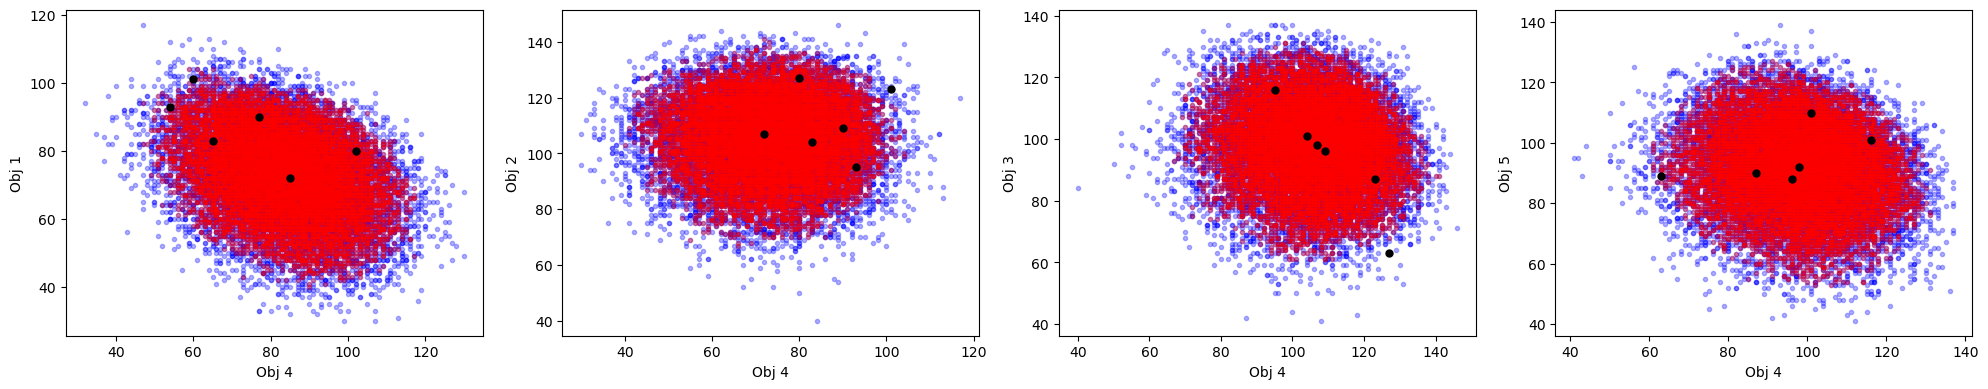

In [29]:
fig = plt.figure(figsize=(20, 4))
ax0 = fig.add_subplot(1, 4, 1)
ax1 = fig.add_subplot(1, 4, 2)
ax2 = fig.add_subplot(1, 4, 3)
ax3 = fig.add_subplot(1, 4, 4)

ax0.plot(pf[:, 0], pf[:, 1], 'bo', alpha=0.3, markersize=3)
ax0.plot(pf_dense[:, 0], pf_dense[:, 1], 'ro', alpha=0.3, markersize=3)
ax0.plot(selected_sols[:, 0], selected_sols[:, 1], 'ko', alpha=1, markersize=5)
ax0.set_xlabel('Obj 4')
ax0.set_ylabel('Obj 1')

ax1.plot(pf[:, 1], pf[:, 2], 'bo', alpha=0.3, markersize=3)
ax1.plot(pf_dense[:, 1], pf_dense[:, 2], 'ro', alpha=0.3, markersize=3)
ax1.plot(selected_sols[:, 1], selected_sols[:, 2], 'ko', alpha=1, markersize=5)
ax1.set_xlabel('Obj 4')
ax1.set_ylabel('Obj 2')

ax2.plot(pf[:, 2], pf[:, 3], 'bo', alpha=0.3, markersize=3)    
ax2.plot(pf_dense[:, 2], pf_dense[:, 3], 'ro', alpha=0.3, markersize=3)
ax2.plot(selected_sols[:, 2], selected_sols[:, 3], 'ko', alpha=1, markersize=5)
ax2.set_xlabel('Obj 4')
ax2.set_ylabel('Obj 3')

ax3.plot(pf[:, 3], pf[:, 4], 'bo', alpha=0.3, markersize=3)
ax3.plot(pf_dense[:, 3], pf_dense[:, 4], 'ro', alpha=0.3, markersize=3)
ax3.plot(selected_sols[:, 3], selected_sols[:, 4], 'ko', alpha=1, markersize=5)
ax3.set_xlabel('Obj 4')
ax3.set_ylabel('Obj 5')

fig.tight_layout()
plt.show()

In [19]:
dist = np.linalg.norm(selected_sols - ref_sol, axis=1)
new_aspi = selected_sols[dist.argmin()]

# selected_sols_ranked = selected_sols[dist.argsort()]
# weights = 1.0 / np.linspace(1, np.exp(3), selected_sols.shape[0])
# weights /= weights.sum()
# new_aspi = weights @ selected_sols_ranked

In [20]:
print(np.linalg.norm(new_aspi - ref_sol))

23.194827009486403


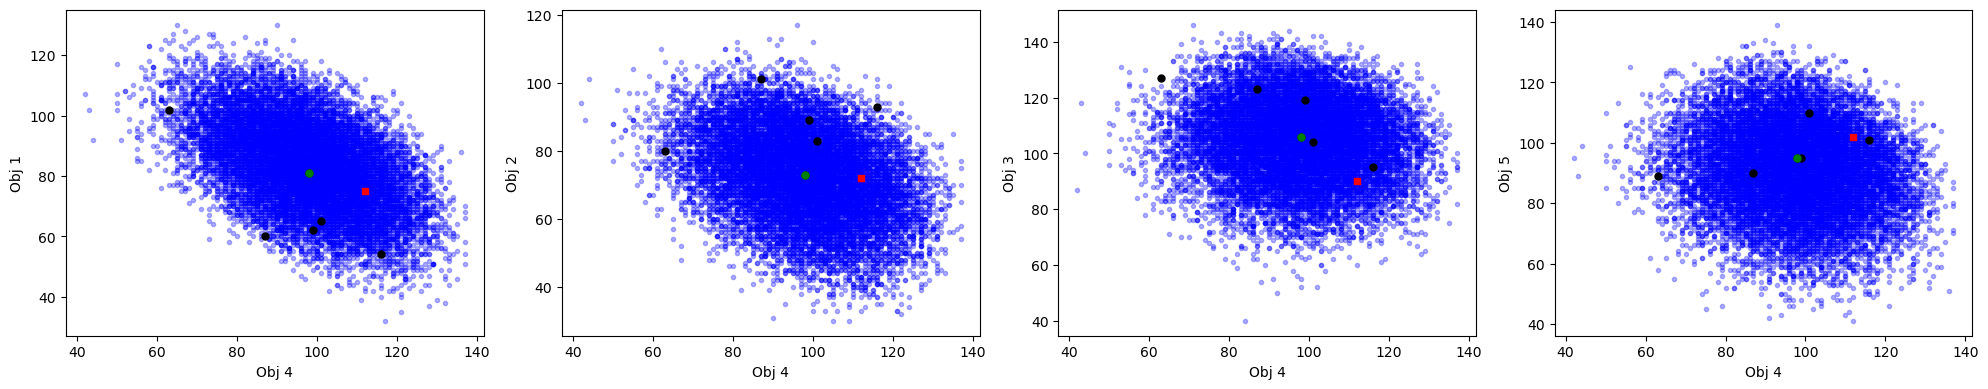

In [21]:
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(20, 4))
ax0 = fig.add_subplot(1, 4, 1)
ax1 = fig.add_subplot(1, 4, 2)
ax2 = fig.add_subplot(1, 4, 3)
ax3 = fig.add_subplot(1, 4, 4)

ax0.plot(pf[:, 3], pf[:, 0], 'bo', alpha=0.3, markersize=3)
ax0.plot(selected_sols[:, 3], selected_sols[:, 0], 'ko', alpha=1, markersize=5)
ax0.plot(new_aspi[3], new_aspi[0], 'go', alpha=1, markersize=5)
ax0.plot(ref_sol[3], ref_sol[0], 'rs', alpha=1, markersize=5)
ax0.set_xlabel('Obj 4')
ax0.set_ylabel('Obj 1')

ax1.plot(pf[:, 3], pf[:, 1], 'bo', alpha=0.3, markersize=3)
ax1.plot(selected_sols[:, 3], selected_sols[:, 1], 'ko', alpha=1, markersize=5)
ax1.plot(new_aspi[3], new_aspi[1], 'go', alpha=1, markersize=5)
ax1.plot(ref_sol[3], ref_sol[1], 'rs', alpha=1, markersize=5)
ax1.set_xlabel('Obj 4')
ax1.set_ylabel('Obj 2')

ax2.plot(pf[:, 3], pf[:, 2], 'bo', alpha=0.3, markersize=3)
ax2.plot(selected_sols[:, 3], selected_sols[:, 2], 'ko', alpha=1, markersize=5)
ax2.plot(new_aspi[3], new_aspi[2], 'go', alpha=1, markersize=5)
ax2.plot(ref_sol[3], ref_sol[2], 'rs', alpha=1, markersize=5)
ax2.set_xlabel('Obj 4')
ax2.set_ylabel('Obj 3')

ax3.plot(pf[:, 3], pf[:, 4], 'bo', alpha=0.3, markersize=3)
ax3.plot(selected_sols[:, 3], selected_sols[:, 4], 'ko', alpha=1, markersize=5)
ax3.plot(new_aspi[3], new_aspi[4], 'go', alpha=1, markersize=5)
ax3.plot(ref_sol[3], ref_sol[4], 'rs', alpha=1, markersize=5)
ax3.set_xlabel('Obj 4')
ax3.set_ylabel('Obj 5')

fig.tight_layout()
plt.show()